In [21]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import os

# --------------------------------------------------
# Load station CSV (already created by you)
# --------------------------------------------------
df = pd.read_csv("each_file_skew_classification.csv")

# convert to GeoDataFrame
geometry = [Point(lon, lat) for lon, lat in zip(df.Lon, df.Lat)]
gdf_stations = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# --------------------------------------------------
# Load tectonic unit shapefiles
# --------------------------------------------------
TECTONIC_DIR = "../data/mccourt_2013_tectonic_units"

unit_files = {
    "archean": "archaean.shp",
    "paleoproterozoic_shields": "paleoproterozoic_shields.shp",
    "paleoproterozoic_belts": "paleoproterozoic_belts.shp",
    "mesoproterozoic_belts": "mesoproterozoic_belts.shp",
    "neoproterozoic": "neoproterozoic.shp",
    "limpopo": "limpopo.shp"
}

# initialize column
gdf_stations["Tectonic_Unit"] = "unknown"

# --------------------------------------------------
# Spatial join manually (unit by unit)
# --------------------------------------------------
for unit, shp in unit_files.items():
    path = os.path.join(TECTONIC_DIR, shp)
    if not os.path.exists(path):
        print(f"Missing {path}")
        continue

    gdf_unit = gpd.read_file(path)

    # ensure same CRS
    if gdf_unit.crs != gdf_stations.crs:
        gdf_unit = gdf_unit.to_crs(gdf_stations.crs)

    # spatial join
    joined = gpd.sjoin(
        gdf_stations,
        gdf_unit,
        how="left",
        predicate="within"
    )

    # assign tectonic unit where matched
    mask = joined.index_right.notna()
    gdf_stations.loc[mask, "Tectonic_Unit"] = unit

# --------------------------------------------------
# Save final table
# --------------------------------------------------
out = "each_file_skew_classification_with_units.csv"
gdf_stations.drop(columns="geometry").to_csv(out, index=False)

print("Saved", out)
print(gdf_stations["Tectonic_Unit"].value_counts())


Saved each_file_skew_classification_with_units.csv
Tectonic_Unit
archean                     269
paleoproterozoic_shields    165
neoproterozoic              155
mesoproterozoic_belts        73
limpopo                      69
paleoproterozoic_belts       53
Name: count, dtype: int64


In [26]:
import os, re, numpy as np, pandas as pd
from mt_metadata.transfer_functions import TF

mu0 = 4*np.pi*1e-7

# -------------------------------
# Load 1D sites
# -------------------------------
skew_df = pd.read_csv("each_file_skew_classification_with_units.csv")

good_sites = set(skew_df.loc[skew_df.Is1D, "Site"])

print("Total 1D sites:", len(good_sites))

# -------------------------------
# Clean output directory FIRST
# -------------------------------
outdir = "determinant_per_station"
os.makedirs(outdir, exist_ok=True)

for f in os.listdir(outdir):
    if f.endswith(".csv"):
        os.remove(os.path.join(outdir, f))

print("Old determinant files removed")

# -------------------------------
# Helpers
# -------------------------------
def sanitize(path):
    with open(path,"r",errors="ignore") as f:
        lines = f.readlines()
    out=[]
    for l in lines:
        if l.strip().startswith(">!"):
            out.append(l); continue
        l=re.sub(r"\*+"," -9999 ",l)
        l=re.sub(r"(?<![0-9eE+\-])0\.0(?![0-9eE+\-])"," -9999 ",l)
        out.append(l)
    return "".join(out)

def read_tf(path):
    with open("_tmp.edi","w") as f:
        f.write(sanitize(path))
    tf = TF()
    tf.read("_tmp.edi")
    return tf

# -------------------------------
# Compute determinant ONLY for 1D
# -------------------------------
edi_folder = "../data/all_station_EDI_data"
count = 0

for f in sorted(os.listdir(edi_folder)):
    if not f.lower().endswith(".edi"):
        continue

    site = f.replace(".edi","")
    if site not in good_sites:
        continue

    tf = read_tf(os.path.join(edi_folder, f))
    Z = np.array(tf.impedance.data, complex)
    periods = np.array(tf.period.data, float)

    Zdet = np.sqrt(Z[:,0,1]*Z[:,1,0] - Z[:,0,0]*Z[:,1,1])
    omega = 2*np.pi/periods
    rho = np.abs(Zdet)**2 / (mu0 * omega)
    phase = np.angle(Zdet, deg=True)

    pd.DataFrame({
        "period_s": periods,
        "rho_det": rho,
        "phase_det_deg": phase
    }).to_csv(f"{outdir}/{site}_det.csv", index=False)

    count += 1

print("Determinant computed for", count, "1D sites only")


Total 1D sites: 293
Old determinant files removed
Determinant computed for 293 1D sites only


In [27]:
import glob, pandas as pd

files = glob.glob("determinant_per_station/*_det.csv")
print("Determinant files:", len(files))

skew_df = pd.read_csv("each_file_skew_classification.csv")
print("1D sites:", (skew_df.Is1D==True).sum())


Determinant files: 293
1D sites: 293


In [28]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# Load station metadata with units
# ----------------------------------
info = pd.read_csv("each_file_skew_classification_with_units.csv")

# only 1D stations
info = info[info["Is1D"] == True]

DET_DIR = "determinant_per_station"
OUT_DIR = "qc_plots_by_unit"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------------
# Loop over tectonic units
# ----------------------------------
for unit in sorted(info["Tectonic_Unit"].unique()):

    unit_df = info[info["Tectonic_Unit"] == unit]

    files = []
    for site in unit_df["Site"]:
        f = os.path.join(DET_DIR, f"{site}_det.csv")
        if os.path.exists(f):
            files.append(f)

    if len(files) == 0:
        continue

    ncols = 6
    n = len(files)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(4 * ncols, 3 * nrows))

    for i, f in enumerate(files):
        df = pd.read_csv(f)

        ax = fig.add_subplot(nrows, ncols, i + 1)
        ax.loglog(df["period_s"], df["rho_det"], "o-", markersize=2)

        ax.set_title(
            os.path.basename(f).replace("_det.csv", ""),
            fontsize=7
        )

        ax.grid(True, which="both", alpha=0.4)
        ax.tick_params(labelsize=6)

    plt.suptitle(
        f"Tectonic unit: {unit}  (n = {len(files)})",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out = os.path.join(OUT_DIR, f"qc_{unit}.png")
    plt.savefig(out, dpi=200)
    plt.close()

    print("Saved", out)


Saved qc_plots_by_unit/qc_archean.png
Saved qc_plots_by_unit/qc_limpopo.png
Saved qc_plots_by_unit/qc_mesoproterozoic_belts.png
Saved qc_plots_by_unit/qc_neoproterozoic.png
Saved qc_plots_by_unit/qc_paleoproterozoic_belts.png
Saved qc_plots_by_unit/qc_paleoproterozoic_shields.png


In [38]:
import pandas as pd

# ---------------------------
# Your selected 24 stations
# ---------------------------
stations = [
   # Archean
    "SAMTEX.bot228.2005",
    "SAMTEX.rtz401.2005",
    "SAMTEX.kap067.2003",
    "SAMTEX.bot407.2005",

    # Limpopo
    "SAMTEX.bot416.2005",
    "SAMTEX.kal017.2008",
    "SAMTEX.san006.2008",
    "SAMTEX.san008.2008",

    # Mesoproterozoic belts
    "SAMTEX.kap010.2003",
    "SAMTEX.zim128.2005",
    "SAMTEX.mof102.2005",
    "SAMTEX.NEN003.2006",

    # Neoproterozoic
    "SAMTEX.ELZ291A.2008",
    "SAMTEX.dmb017.2006",
    "SAMTEX.oka008.2006",
    "SAMTEX.CPV027.2006",

    # Paleoproterozoic belts
    "SAMTEX.k2g006.2006",
    "SAMTEX.mof107.2005",
    "SAMTEX.san011.2008",
    "SAMTEX.mak002.2006",

    # Paleoproterozoic shields
    "SAMTEX.kim422.2004",
    "SAMTEX.kim432.2004",
    "SAMTEX.kim435.2004",
    "SAMTEX.rtz417.2005"
]

# ---------------------------
# Load CSV
# ---------------------------
df = pd.read_csv("each_file_skew_classification_with_units.csv")

available_sites = set(df["Site"].astype(str))

# ---------------------------
# Check presence
# ---------------------------
present = []
missing = []

for s in stations:
    if s in available_sites:
        present.append(s)
    else:
        missing.append(s)

# ---------------------------
# Print results
# ---------------------------
print(f"Total selected stations: {len(stations)}")
print(f"Present in CSV: {len(present)}")
print(f"Missing from CSV: {len(missing)}")

print("\nPresent stations:")
for s in present:
    print(" ", s)

print("\nMissing stations:")
for s in missing:
    print(" ", s)


Total selected stations: 24
Present in CSV: 24
Missing from CSV: 0

Present stations:
  SAMTEX.bot228.2005
  SAMTEX.rtz401.2005
  SAMTEX.kap067.2003
  SAMTEX.bot407.2005
  SAMTEX.bot416.2005
  SAMTEX.kal017.2008
  SAMTEX.san006.2008
  SAMTEX.san008.2008
  SAMTEX.kap010.2003
  SAMTEX.zim128.2005
  SAMTEX.mof102.2005
  SAMTEX.NEN003.2006
  SAMTEX.ELZ291A.2008
  SAMTEX.dmb017.2006
  SAMTEX.oka008.2006
  SAMTEX.CPV027.2006
  SAMTEX.k2g006.2006
  SAMTEX.mof107.2005
  SAMTEX.san011.2008
  SAMTEX.mak002.2006
  SAMTEX.kim422.2004
  SAMTEX.kim432.2004
  SAMTEX.kim435.2004
  SAMTEX.rtz417.2005

Missing stations:


In [39]:
import pandas as pd

# ---------------------------
# Selected 24 stations
# ---------------------------
stations = [
    # Archean
    "SAMTEX.bot228.2005",
    "SAMTEX.rtz401.2005",
    "SAMTEX.kap067.2003",
    "SAMTEX.bot407.2005",

    # Limpopo
    "SAMTEX.bot416.2005",
    "SAMTEX.kal017.2008",
    "SAMTEX.san006.2008",
    "SAMTEX.san008.2008",

    # Mesoproterozoic belts
    "SAMTEX.kap010.2003",
    "SAMTEX.zim128.2005",
    "SAMTEX.mof102.2005",
    "SAMTEX.NEN003.2006",

    # Neoproterozoic
    "SAMTEX.ELZ291A.2008",
    "SAMTEX.dmb017.2006",
    "SAMTEX.oka008.2006",
    "SAMTEX.CPV027.2006",

    # Paleoproterozoic belts
    "SAMTEX.k2g006.2006",
    "SAMTEX.mof107.2005",
    "SAMTEX.san011.2008",
    "SAMTEX.mak002.2006",

    # Paleoproterozoic shields
    "SAMTEX.kim422.2004",
    "SAMTEX.kim432.2004",
    "SAMTEX.kim435.2004",
    "SAMTEX.rtz417.2005"
]

# ---------------------------
# Load master table
# ---------------------------
df = pd.read_csv("each_file_skew_classification_with_units.csv")

# filter only selected stations
selected_df = df[df["Site"].isin(stations)].copy()

# safety check
assert len(selected_df) == 24, f"Expected 24 stations, got {len(selected_df)}"

# save
selected_df.to_csv("selected_24_stations.csv", index=False)

print("Saved selected_24_stations.csv")
print(selected_df[["Site", "Tectonic_Unit", "Lat", "Lon"]])


Saved selected_24_stations.csv
                    Site             Tectonic_Unit        Lat        Lon
86    SAMTEX.CPV027.2006            neoproterozoic -17.710283  23.860692
117  SAMTEX.ELZ291A.2008            neoproterozoic -17.723783  23.930275
194   SAMTEX.NEN003.2006     mesoproterozoic_belts -21.632061  20.853275
271   SAMTEX.bot228.2005                   archean -24.139922  23.144806
281   SAMTEX.bot407.2005                   archean -24.345728  25.525831
290   SAMTEX.bot416.2005                   limpopo -22.966006  26.376389
313   SAMTEX.dmb017.2006            neoproterozoic -21.191839  18.524442
338   SAMTEX.k2g006.2006    paleoproterozoic_belts -22.530172  21.833108
363   SAMTEX.kal017.2008                   limpopo -22.644700  24.756389
380   SAMTEX.kap010.2003     mesoproterozoic_belts -31.147950  21.466942
436   SAMTEX.kap067.2003                   archean -23.174442  28.948056
490   SAMTEX.kim422.2004  paleoproterozoic_shields -25.106867  19.952028
500   SAMTEX.kim432.

Loaded tectonic unit: afr_g2014_2013_0
Loaded tectonic unit: paleoproterozoic_belts
Loaded tectonic unit: paleoproterozoic_shields
Loaded tectonic unit: mesoproterozoic_belts
Loaded tectonic unit: neoproterozoic
Loaded tectonic unit: archaean
Loaded tectonic unit: limpopo


/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/creation.py:460: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/dissertation_env/lib/python3.13/site-packages/shapely/c

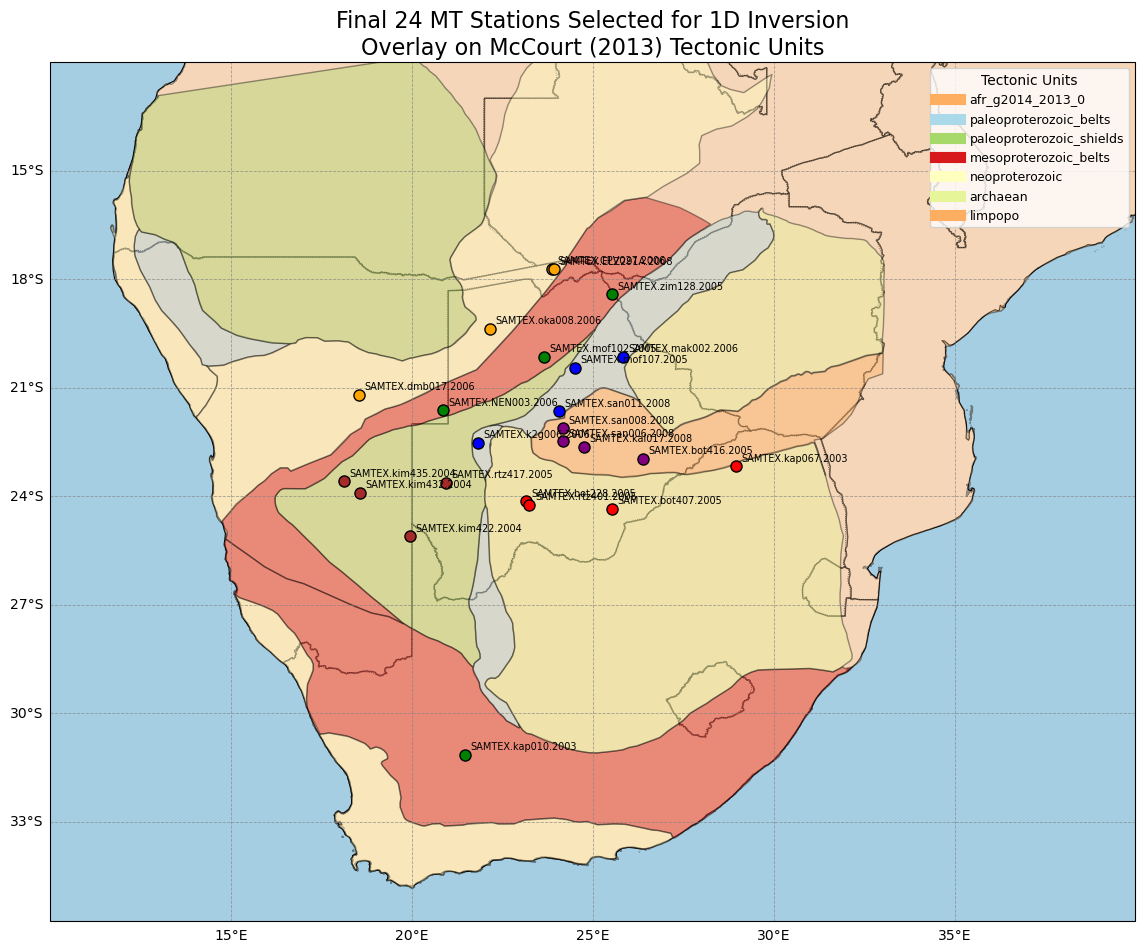

Saved final_24_stations_geology_map.png


In [40]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import ShapelyFeature

# ----------------------------------------------------
# INPUT FILES
# ----------------------------------------------------
STATION_CSV = "selected_24_stations.csv"
TECTONIC_DIR = "../data/mccourt_2013_tectonic_units"

# ----------------------------------------------------
# MAP EXTENT (Southern Africa)
# ----------------------------------------------------
ZOOM_EXTENT = [10, 40, -35, -12]   # [lon_min, lon_max, lat_min, lat_max]

# ----------------------------------------------------
# LOAD SELECTED 24 STATIONS
# ----------------------------------------------------
stations = pd.read_csv(STATION_CSV)

# ----------------------------------------------------
# LOAD ALL TECTONIC SHAPEFILES AUTOMATICALLY
# ----------------------------------------------------
def load_all_shapefiles(directory, clip_extent):
    layers = {}

    for file in os.listdir(directory):
        if file.lower().endswith(".shp"):
            name = file.replace(".shp", "")
            path = os.path.join(directory, file)

            gdf = gpd.read_file(path)

            # ensure WGS84
            if gdf.crs and gdf.crs.to_string() != "EPSG:4326":
                gdf = gdf.to_crs("EPSG:4326")

            clipped = gdf.cx[
                clip_extent[0]:clip_extent[1],
                clip_extent[2]:clip_extent[3]
            ]

            if len(clipped) > 0:
                layers[name] = clipped
                print(f"Loaded tectonic unit: {name}")

    return layers

tectonic_layers = load_all_shapefiles(TECTONIC_DIR, ZOOM_EXTENT)

# ----------------------------------------------------
# PLOT MAP
# ----------------------------------------------------
plt.figure(figsize=(14, 14))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(ZOOM_EXTENT)

# Base map
ax.add_feature(cfeature.LAND, facecolor="#f2f2f2")
ax.add_feature(cfeature.OCEAN, facecolor="#a6cee3")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

# ----------------------------------------------------
# PLOT TECTONIC UNITS
# ----------------------------------------------------
unit_colors = [
    "#fdae61", "#abd9e9", "#a6d96a",
    "#d7191c", "#ffffbf", "#e6f598"
]

for i, (name, gdf) in enumerate(tectonic_layers.items()):
    color = unit_colors[i % len(unit_colors)]

    feat = ShapelyFeature(
        gdf.geometry,
        ccrs.PlateCarree(),
        facecolor=color,
        edgecolor="black",
        alpha=0.4
    )

    ax.add_feature(feat)
    ax.plot([], [], color=color, linewidth=8, label=name)

# ----------------------------------------------------
# PLOT SELECTED 24 STATIONS
# ----------------------------------------------------
unit_marker_colors = {
    "archean": "red",
    "limpopo": "purple",
    "mesoproterozoic_belts": "green",
    "neoproterozoic": "orange",
    "paleoproterozoic_belts": "blue",
    "paleoproterozoic_shields": "brown"
}

for _, row in stations.iterrows():
    color = unit_marker_colors.get(row["Tectonic_Unit"], "black")

    ax.plot(
        row["Lon"], row["Lat"],
        marker="o",
        markersize=8,
        markeredgecolor="black",
        color=color,
        transform=ccrs.PlateCarree(),
        zorder=30
    )

    # station label
    ax.text(
        row["Lon"] + 0.15,
        row["Lat"] + 0.15,
        row["Site"],
        fontsize=7,
        transform=ccrs.PlateCarree(),
        zorder=31
    )

# ----------------------------------------------------
# GRIDLINES
# ----------------------------------------------------
gl = ax.gridlines(draw_labels=True, linewidth=0.6,
                  linestyle="--", color="gray", alpha=0.7)
gl.top_labels = False
gl.right_labels = False

# ----------------------------------------------------
# TITLE + LEGEND
# ----------------------------------------------------
plt.title(
    "Final 24 MT Stations Selected for 1D Inversion\n"
    "Overlay on McCourt (2013) Tectonic Units",
    fontsize=16
)

plt.legend(
    loc="upper right",
    title="Tectonic Units",
    fontsize=9,
    title_fontsize=10
)

# ----------------------------------------------------
# SAVE & SHOW
# ----------------------------------------------------
plt.savefig("final_24_stations_geology_map.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved final_24_stations_geology_map.png")


Total selected stations: 24


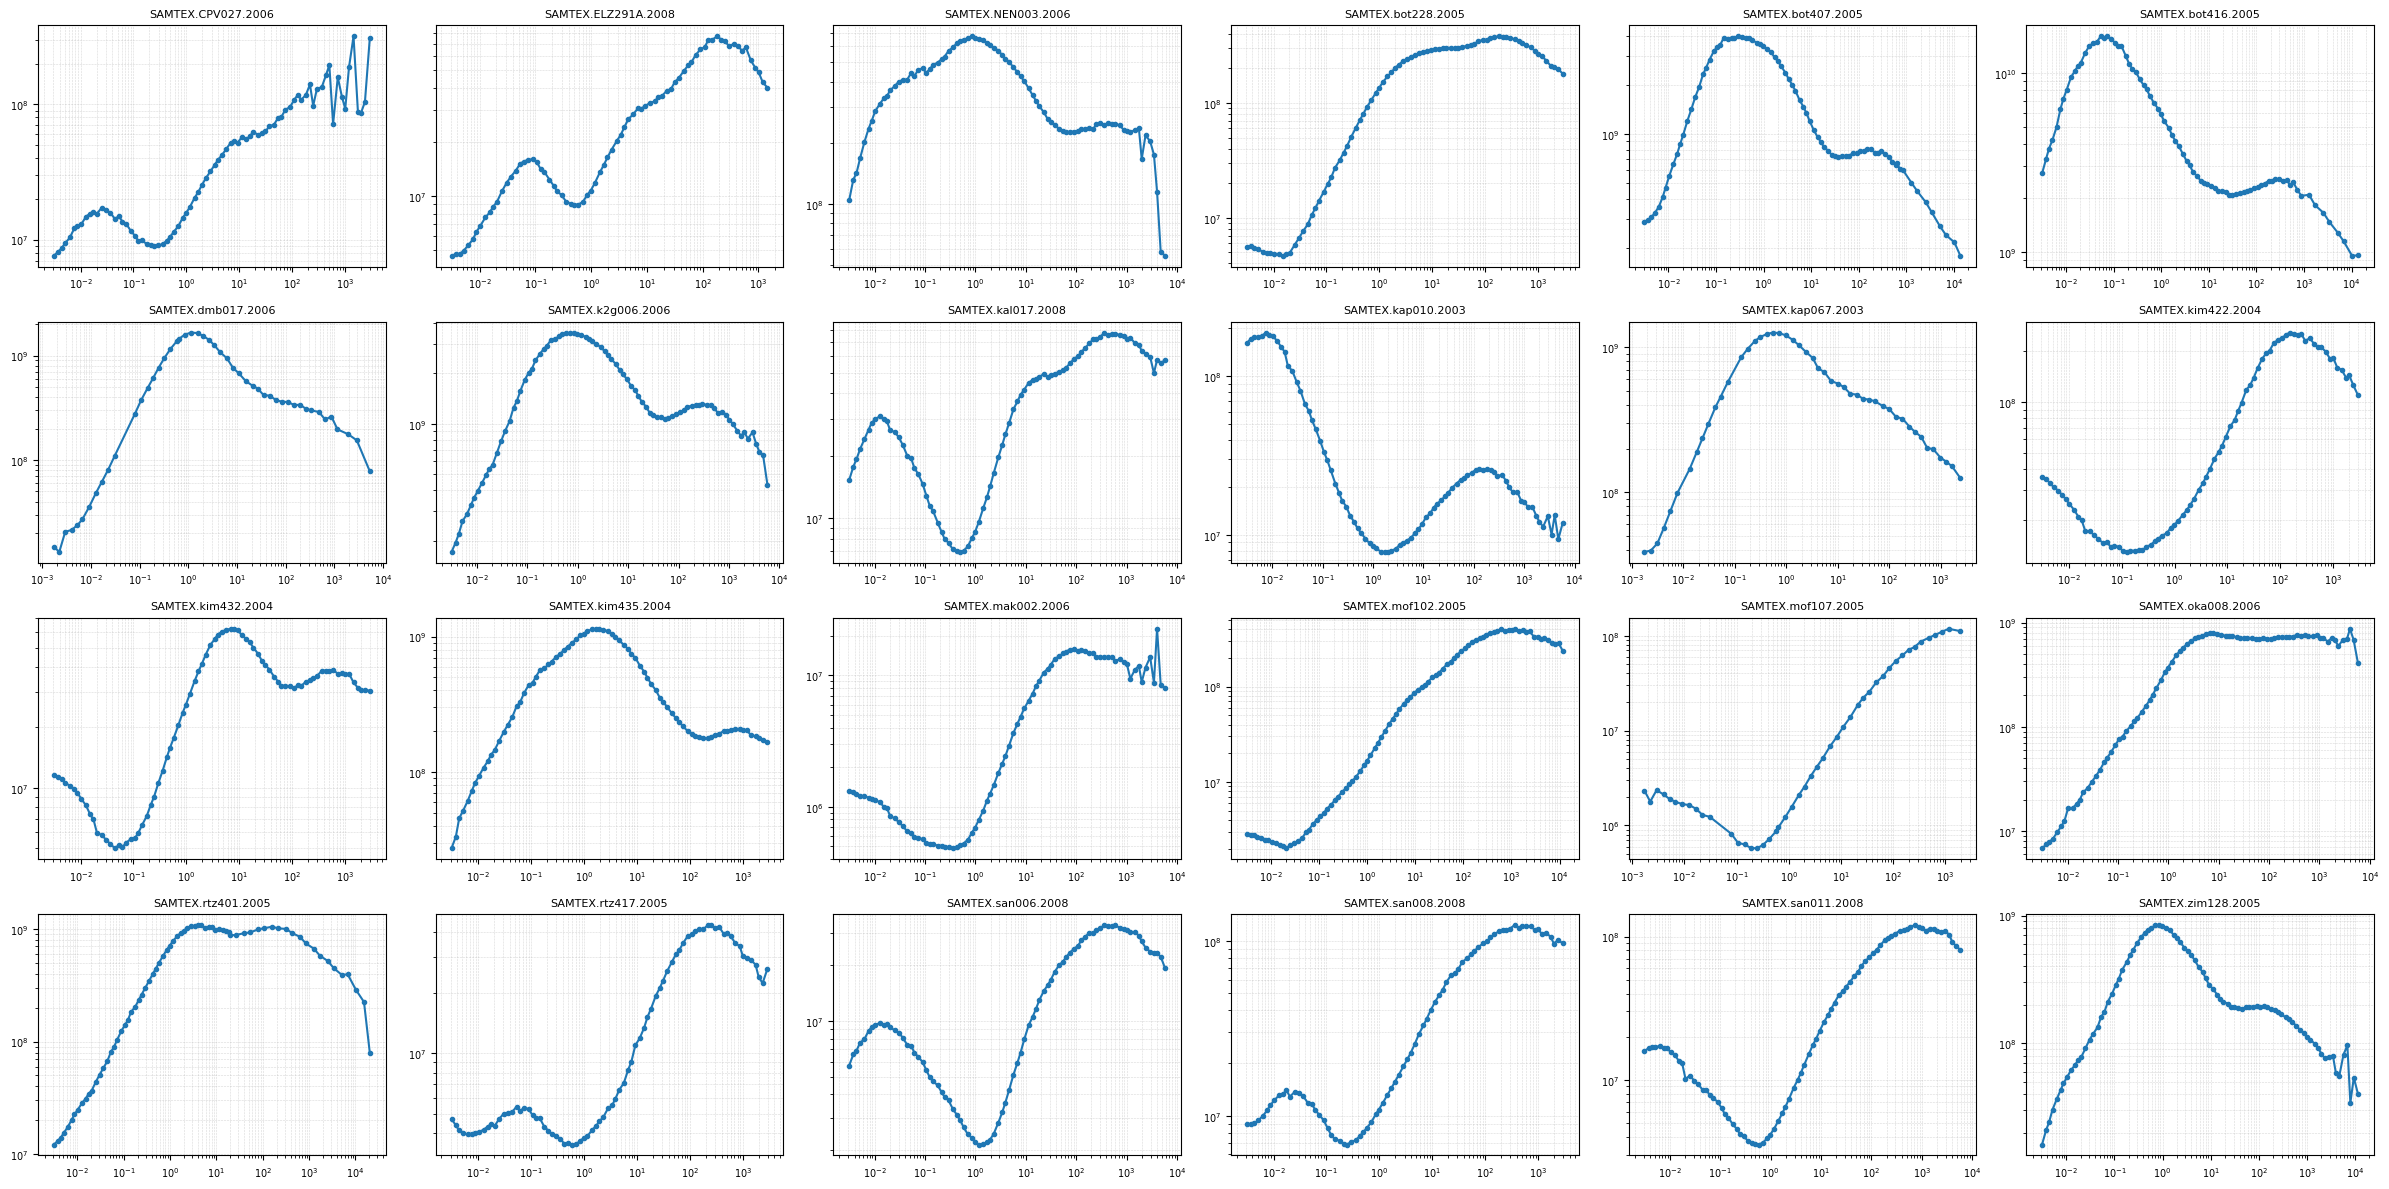

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# INPUTS
# ----------------------------------------------------
PER_STATION_DIR = "determinant_per_station"
SELECTED_CSV = "selected_24_stations.csv"
OUT_PNG = "qc_grid_selected_24.png"

# ----------------------------------------------------
# LOAD SELECTED 24 STATIONS
# ----------------------------------------------------
sel = pd.read_csv(SELECTED_CSV)

# build list of determinant csv files (ordered as in CSV)
station_csvs = []
for site in sel["Site"]:
    f = os.path.join(PER_STATION_DIR, f"{site}_det.csv")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing determinant file: {f}")
    station_csvs.append(f)

print("Total selected stations:", len(station_csvs))

# ----------------------------------------------------
# QC GRID PLOT FUNCTION
# ----------------------------------------------------
def plot_grid(csv_files, ncols=6, save_png="qc_grid.png"):
    n = len(csv_files)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(4 * ncols, 3 * nrows))

    for i, f in enumerate(csv_files):
        df = pd.read_csv(f)

        periods = df["period_s"].values
        rho = df["rho_det"].values

        ax = fig.add_subplot(nrows, ncols, i + 1)
        ax.loglog(periods, rho, "o-", markersize=3)

        ax.set_title(
            os.path.basename(f).replace("_det.csv", ""),
            fontsize=8
        )

        ax.grid(True, which="both", lw=0.4, ls="--", alpha=0.5)
        ax.tick_params(axis="both", labelsize=7)

    plt.tight_layout()
    plt.savefig(save_png, dpi=300)
    plt.show()   # 🔥 this displays the figure


# ----------------------------------------------------
# PLOT
# ----------------------------------------------------
plot_grid(station_csvs, ncols=6, save_png=OUT_PNG)
